# Difference of two proportions

---

#### Summary videos

- [Sampling distributions and standard error calculations for proportions](https://youtu.be/_iFAZgpWsx0?si=SANEM7BctO39YeSH) (16 minutes)


#### Walkthrough videos

- [Confidence intervals for the difference of two proportions](https://drive.google.com/file/d/17RSLQ3_0J2J5WSQFfsbRhI56zs8rqzP1/view?usp=sharing) (13 minutes)
- [Hypothesis testing for the difference of two proportions](https://drive.google.com/file/d/1y9xyrv1-K0UECcwCG1Uc9LZOoNKlqfuv/view?usp=sharing) (15 minutes)

---

How can we extend our ideas about confidence intervals and hypothesis tests to let us compare two proportions?

## Confidence intervals for the difference of two proportions

### Examples 6.11 and 6.12 (page 218)

We consider an experiment for patients who underwent cardiopulmonary resuscitation (CPR) for a heart attack and were subsequently admitted to a hospital. These patients were randomly divided into a treatment group where they received a blood thinner or the control group where they did not receive a blood thinner. The outcome variable of interest was whether the patients survived for at least 24 hours. The results are summarized in the table below.

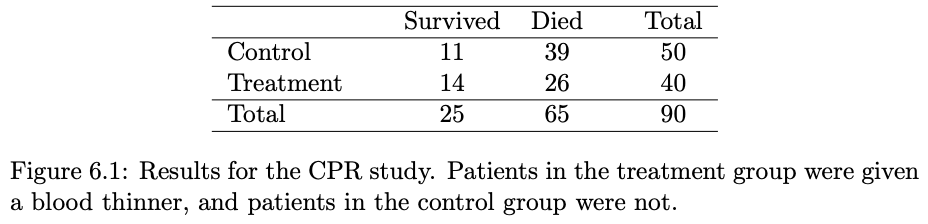

### Exercise

- What proportion of the control group survived? Call this $\hat{p_c}$.
- What proportion of the treatment group survived? Call this $\hat{p_t}$.
- Is $\hat{p_c}$ equal to $\hat{p_t}$? If not, what's the difference?
- Is it possible that the difference (if any) is due to chance?

In [ ]:
import warnings
warnings.filterwarnings("ignore")

p_hat_c = 11/50
p_hat_t = 14/40

p_hat_diff = p_hat_t - p_hat_c

print(f"Survival rate in control group: {p_hat_c}")
print(f"Survival rate in treatment group: {p_hat_t}")
print(f"Difference in survival rates: {p_hat_diff}")

Survival rate in control group: 0.22
Survival rate in treatment group: 0.35
Difference in survival rates: 0.12999999999999998


We'll use $\hat{p_t} - \hat{p_c}$ as a point estimate for the true difference in proportions, $p_t - p_c$. But, before we proceed with any statistical inference, we have to be careful to make sure a normal distribution is a reasonable model. Below is a summary from page 217 of the textbook.

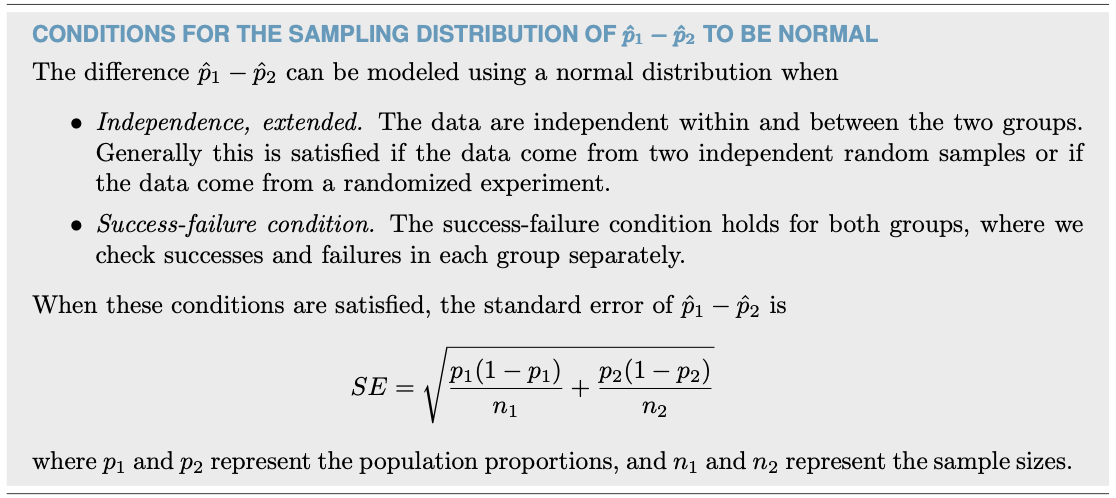

> Note, the standard error formula is actually a consequence of the formula for variance of a linear combination of random variables from Section 3.4!

### Exercise

- Check whether or not the conditions above are satisfied for the CPR study.
- Create and interpret a 90% confidence interval of the difference for the survival rates in the CPR study.
- Based on this confidence interval, can you say whether blood thinners affect the outcomes of patients who have undergone CPR?
- Could your conclusions change if you altered the confidence level? How so?

In [ ]:
# Check the success failure conditions
# The number of expected successes and failures should be more than 10 in *each group*.

print(f"Control successes: {0.22 * 50}")
print(f"Control failures: {(1 - 0.22) * 50}")
print("---")
print(f"Treatment successes: {(0.35) * 40}")
print(f"Treatment failures: {(1 - 0.35) * 40}")

Control successes: 11.0
Control failures: 39.0
---
Treatment successes: 14.0
Treatment failures: 26.0


In [ ]:
# Create a 90% confidence interval

import numpy as np

confidence_level = 0.90

z_star = 1.65

p_hat_diff = 0.13

std_error = np.sqrt(
  (0.22 * (1 - 0.22))/50 + (0.35 * (1 - 0.35))/40
)

margin_of_error = z_star * std_error

print(f"Point estimate: {p_hat_diff}")
print(f"Standard error: {std_error}")
print(f"Margin of error: {margin_of_error}")
print(
  f"{confidence_level * 100}% confidence interval: ({round(p_hat_diff - margin_of_error, 4)}, {round(p_hat_diff + margin_of_error, 4)})"
)

Point estimate: 0.13
Standard error: 0.09549607321769832
Margin of error: 0.15756852080920222
90.0% confidence interval: (-0.0276, 0.2876)


## Hypothesis testing for the difference of two proportions

### Example
A 30-year study was conducted with nearly 90,000 female participants. During a 5-year screening period, each woman was randomized to one of two groups:

- in the first group, women received regular mammograms to screen for breast cancer;
- in the second group, women received regular non-mammogram breast cancer exams.

No intervention was made during the following 25 years of the study, and we'll consider death resulting from breast cancer over the full 30-year period. Results from the study are summarized in the table below, from page 219 of the textbook.

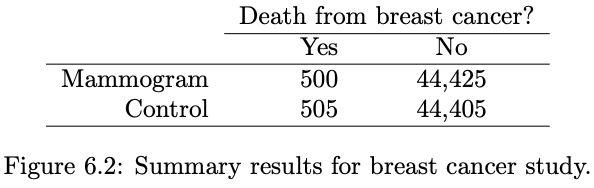

### Exercise

- Find the proportion of deaths in each group.
- Does it appear that mammograms are more effective than non-mammogram breast cancer exams?

In [ ]:
# Find the proportion of deaths in each group.

p_hat_mgm = 500 / (500 + 44425)
p_hat_ctrl = 505 / (505 + 44405)

print(f"Death rate for mammogram group: {p_hat_mgm}")
print(f"Death rate for control group: {p_hat_ctrl}")
print(f"Difference in death rates: {p_hat_mgm - p_hat_ctrl}")

Death rate for mammogram group: 0.011129660545353366
Death rate for control group: 0.011244711645513248
Difference in death rates: -0.00011505110015988182


- Set up hypotheses to test whether there was a difference in breast cancer deaths in the mammogram and control groups.
  - Call $p_{mgm}$ the proportion of the `Mammogram` group who died.
  - Call $p_{ctrl}$ the proportion of the `Control` group who died.

Since our null hypothesis is equivalent to

$$ p_{mgm} = p_{ctrl} $$

we use a **pooled proportion** as our best estimate for the true proportion. The pooled proportion is used to check the success-failure condition and to calculate the standard error.

$$ \hat{p}_{pooled} = \dfrac{\text{total number of "successes"}}{\text{total number of cases}}. $$

- Determine the pooled proportion for the breast cancer study.
- Is it reasonable to model the difference in proportions using a normal distribution in this study?
  - Use the pooled proportion to check the success-failure condition.
- Use the pooled proportion to calculate the standard error.
- Using $\alpha = 0.05$, calculate a p-value for the null hypothesis and write an appropriate conclusion.

In [ ]:
# Compute the pooled proportion.

p_pooled = (500 + 505) / (44425 + 44405 + 500 + 505)

print(f"Pooled proportion: {p_pooled}")

Pooled proportion: 0.011187176490232093


In [ ]:
# Check the success-failure condition for each group using the pooled proportion.

print(f"Successes, mammagram group: {p_pooled * (500 + 44425)}")
print(f"Failures, mammagram group: {(1 - p_pooled) * (500 + 44425)}")
print(f"Successes, control group: {p_pooled * (505 + 44405)}")
print(f"Failures, control group: {(1 - p_pooled) * (505 + 44405)}")

Successes, mammagram group: 502.5839038236768
Failures, mammagram group: 44422.41609617633
Successes, control group: 502.41609617632326
Failures, control group: 44407.58390382368


In [ ]:
# Calculate the standard error

import numpy as np

std_error = np.sqrt(
  (p_pooled * (1 - p_pooled))/(500 + 44425) + (p_pooled * (1 - p_pooled))/(505 + 44405)
)

print(std_error)

0.0007018180044843134


In [ ]:
# Calculate the test statistic (Z-score)

((-0.0001) - 0) / (0.0007)

-0.14285714285714288

In [ ]:
# Find p-value and draw a conclusion.

import numpy as np
from scipy.stats import norm

alpha = 0.05

p_hat_diff = p_hat_mgm - p_hat_ctrl
p_null = 0

std_error = np.sqrt(
  (p_pooled * (1 - p_pooled))/(500 + 44425) + (p_pooled * (1 - p_pooled))/(505 + 44405)
)

z_score = (p_hat_diff - p_null)/std_error

p_value = 2 * (1 - norm.cdf(abs(z_score)))

print(f"Point estimate: {p_hat_diff}")
print(f"Null value: {p_null}")
print(f"Standard error: {std_error}")
print(f"Z-score: {z_score}")
print(f"p-value: {p_value}")

if p_value < alpha:
    print('Reject the null hypothesis.')
else:
    print('Fail to reject the null hypothesis.')

Point estimate: -0.00011505110015988182
Null value: 0
Standard error: 0.0007018180044843134
Z-score: -0.16393295615780026
p-value: 0.8697839227860011
Fail to reject the null hypothesis.


---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.